# **Retail Project**

 **Name:**  ***Omondi Terry Wawuye***

**Admission no:** ***26/04122***

 **Date:** ***23rd July, 2026***

# 1. Load and inspect Data.

**Importing needed libraries**

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

**Loading and reading the provided data set**

In [49]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/My Drive/Colab Notebooks/'
retail_sales_data= pd.read_csv(path + 'retail_sales_data.csv')
retail_sales_data['InvoiceDate'] = pd.to_datetime(retail_sales_data['InvoiceDate'])
retail_sales_data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CustomerID,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Country
0,C001,INV-1001,2024-01-03,SKU-A01,Ceramic Coffee Mug,6,4.50,Kenya
1,C002,INV-1002,2024-01-05,SKU-B02,Scented Candle Set,3,12.99,Uganda
2,C003,INV-1003,2024-01-07,SKU-C03,Wooden Picture Frame,2,8.75,Kenya
3,C001,INV-1004,2024-01-10,SKU-D04,Linen Throw Blanket,1,24.99,Kenya
4,C004,INV-1005,2024-01-12,SKU-A01,Ceramic Coffee Mug,12,4.50,Tanzania


**Data Analysis**

In [50]:
#Checking data shape
retail_sales_data.shape

(142, 8)

In [51]:
# Checking columns
retail_sales_data.columns.tolist()

['CustomerID',
 'InvoiceNo',
 'InvoiceDate',
 'StockCode',
 'Description',
 'Quantity',
 'UnitPrice',
 'Country']

In [52]:
# Checking data types
retail_sales_data.dtypes

,0
CustomerID,object
InvoiceNo,object
InvoiceDate,datetime64[ns]
StockCode,object
Description,object
Quantity,int64
UnitPrice,float64
Country,object


**Printing the 1st and last five of the data**

In [53]:
# 1st five
retail_sales_data.head()

,CustomerID,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Country
0,C001,INV-1001,2024-01-03,SKU-A01,Ceramic Coffee Mug,6,4.50,Kenya
1,C002,INV-1002,2024-01-05,SKU-B02,Scented Candle Set,3,12.99,Uganda
2,C003,INV-1003,2024-01-07,SKU-C03,Wooden Picture Frame,2,8.75,Kenya
3,C001,INV-1004,2024-01-10,SKU-D04,Linen Throw Blanket,1,24.99,Kenya
4,C004,INV-1005,2024-01-12,SKU-A01,Ceramic Coffee Mug,12,4.50,Tanzania


In [54]:
# Last five
retail_sales_data.tail()

,CustomerID,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Country
137,C042,INV-1138,2024-12-20,SKU-X24,Jute Shopping Bag,30,6.00,Kenya
138,C028,INV-1139,2024-12-22,SKU-A01,Ceramic Coffee Mug,50,4.50,Kenya
139,C003,INV-1140,2024-12-27,SKU-N14,Recycled Glass Bowl,8,13.75,Kenya
140,C043,INV-1141,2024-12-28,SKU-B02,Scented Candle Set,18,12.99,Tanzania
141,C004,INV-1142,2024-12-30,SKU-G07,Personalised Notebook,12,7.25,Tanzania


**Describing the data**

In [55]:
retail_sales_data.describe(include='all')

,CustomerID,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Country
count,142,142,142,142,142,142.000000,142.000000,142
unique,50,142,NaN,26,26,NaN,NaN,4
top,C001,INV-1001,NaN,SKU-A01,Ceramic Coffee Mug,NaN,NaN,Kenya
freq,6,1,NaN,18,18,NaN,NaN,98
mean,NaN,NaN,2024-07-03 01:10:59.154929664,NaN,NaN,11.577465,12.505423,NaN
min,NaN,NaN,2024-01-03 00:00:00,NaN,NaN,1.000000,2.500000,NaN
25%,NaN,NaN,2024-04-03 12:00:00,NaN,NaN,4.000000,5.500000,NaN
50%,NaN,NaN,2024-07-04 00:00:00,NaN,NaN,6.500000,11.500000,NaN
75%,NaN,NaN,2024-10-02 12:00:00,NaN,NaN,14.000000,17.625000,NaN
max,NaN,NaN,2024-12-30 00:00:00,NaN,NaN,60.000000,35.000000,NaN


In [56]:
retail_sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CustomerID   142 non-null    object        
 1   InvoiceNo    142 non-null    object        
 2   InvoiceDate  142 non-null    datetime64[ns]
 3   StockCode    142 non-null    object        
 4   Description  142 non-null    object        
 5   Quantity     142 non-null    int64         
 6   UnitPrice    142 non-null    float64       
 7   Country      142 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 9.0+ KB


**Sentences describing the dataset**

- The dataset contains 142 rows and 8 columns, detailing retail sales and transactions with information such as  customer and invoice IDs, product descriptions quantities, unit price and countries.

- Data contains nulls hence in need of cleaning and filling

# 2. Checking for missing data and data quality

**Checking for missing Valued & Data**

In [57]:
retail_sales_data.isnull().sum()

,0
CustomerID,0
InvoiceNo,0
InvoiceDate,0
StockCode,0
Description,0
Quantity,0
UnitPrice,0
Country,0


There are no missing values

**Checking for duplicate rows**

In [58]:
retail_sales_data.duplicated().sum()

np.int64(0)

*There are no duplicate rows.*

**Checking that Quantity and unit price are always positive**

In [59]:
retail_sales_data[(retail_sales_data['Quantity'] < 0) | (retail_sales_data['UnitPrice'] < 0)].count()

,0
CustomerID,0
InvoiceNo,0
InvoiceDate,0
StockCode,0
Description,0
Quantity,0
UnitPrice,0
Country,0


**Checking that invoice date is within the expected 2024 range**

In [60]:
print(retail_sales_data['InvoiceDate'].min())
print(retail_sales_data['InvoiceDate'].max())

2024-01-03 00:00:00
2024-12-30 00:00:00


*This shows that the 1st and the last both lie within 2024*

**Printing a clean summary of your Data quality findings**

### Data Quality Findings:

*   **Missing Values:** There are no missing values across all columns in the dataset.
*   **Duplicate Rows:** There are no duplicate rows in the dataset.
*   **Quantity and Unit Price:** All `Quantity` and `UnitPrice` values are positive, indicating no invalid negative entries.
*   **InvoiceDate Range:** The `InvoiceDate` column has been successfully converted to datetime objects, and the earliest date found is '2024-01-03', confirming it falls within the expected 2024 range.

# 3. Feature Engineering

In [61]:
# Creating a column of revenue
retail_sales_data['Revenue'] = retail_sales_data['Quantity'] * retail_sales_data['UnitPrice']
#Extract
retail_sales_data['Month'] = retail_sales_data['InvoiceDate'].dt.month
retail_sales_data['MonthName'] = retail_sales_data['InvoiceDate'].dt.strftime('%B')
retail_sales_data['DayOfWeek'] = retail_sales_data['InvoiceDate'].dt.day_name()
retail_sales_data['Quarter'] = retail_sales_data['InvoiceDate'].dt.quarter
# Creating a monthly revenue summary DataFrameusing groupby
monthly=retail_sales_data.groupby(['Month', 'MonthName'])['Revenue'].sum().reset_index().sort_values('Month')
monthly.head()

,Month,MonthName,Revenue
0,1,January,401.20
1,2,February,548.73
2,3,March,496.95
3,4,April,679.92
4,5,May,641.73


In [62]:
#Create an order level summary (Total revenue per invoiceNo)
order_level_summary = retail_sales_data.groupby('InvoiceNo')['Revenue'].sum().reset_index()
order_level_summary.head()

,InvoiceNo,Revenue
0,INV-1001,27.00
1,INV-1002,38.97
2,INV-1003,17.50
3,INV-1004,24.99
4,INV-1005,54.00


In [63]:
# Printing the top 5 row of each new aggregation
print("Top 5 rows of Monthly Revenue Summary:")
print(monthly.head())

print("\nTop 5 rows of Order Level Summary:")
print(order_level_summary.head())

Top 5 rows of Monthly Revenue Summary:
   Month MonthName  Revenue
0      1   January   401.20
1      2  February   548.73
2      3     March   496.95
3      4     April   679.92
4      5       May   641.73

Top 5 rows of Order Level Summary:
  InvoiceNo  Revenue
0  INV-1001    27.00
1  INV-1002    38.97
2  INV-1003    17.50
3  INV-1004    24.99
4  INV-1005    54.00


# 4. Exploratory Analysis & Visualization.

**Chart 1: Monthly Revenue trend line(with peak annonated**

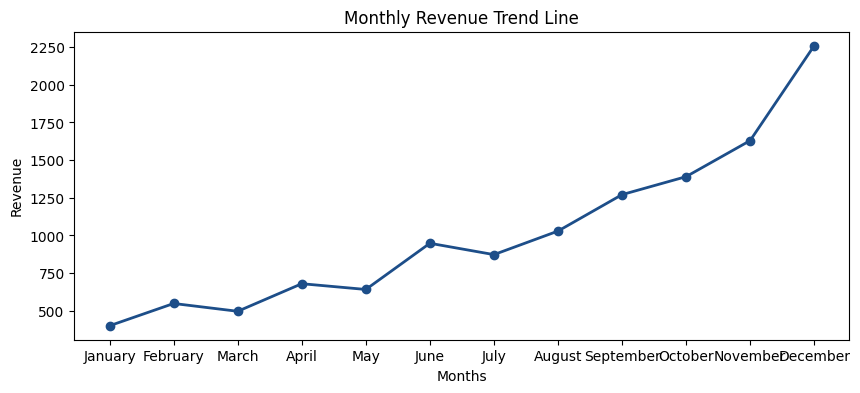

In [64]:
fig, ax= plt.subplots(figsize=(10,4))
ax.plot(monthly['MonthName'], monthly['Revenue'], color= '#1d4e89', marker='o', linewidth=2)
ax.set_title('Monthly Revenue Trend Line')
plt.savefig('Monthly Revenue Trend Line 2024.png')
plt.xlabel('Months')
plt.ylabel('Revenue')
plt.show()

### Interpretation of Monthly Revenue Trend Line:
The monthly revenue trend line shows a clear upward trajectory throughout the year 2024, indicating consistent growth in sales. Revenue starts lower in January and steadily increases, reaching its peak in December. This suggests a strong performance, possibly influenced by seasonal shopping patterns or effective sales strategies implemented over the year. The consistent growth across months is a positive indicator for the business.

**Chart 2: Top ten products by total revenue( Horizontal barchart)**

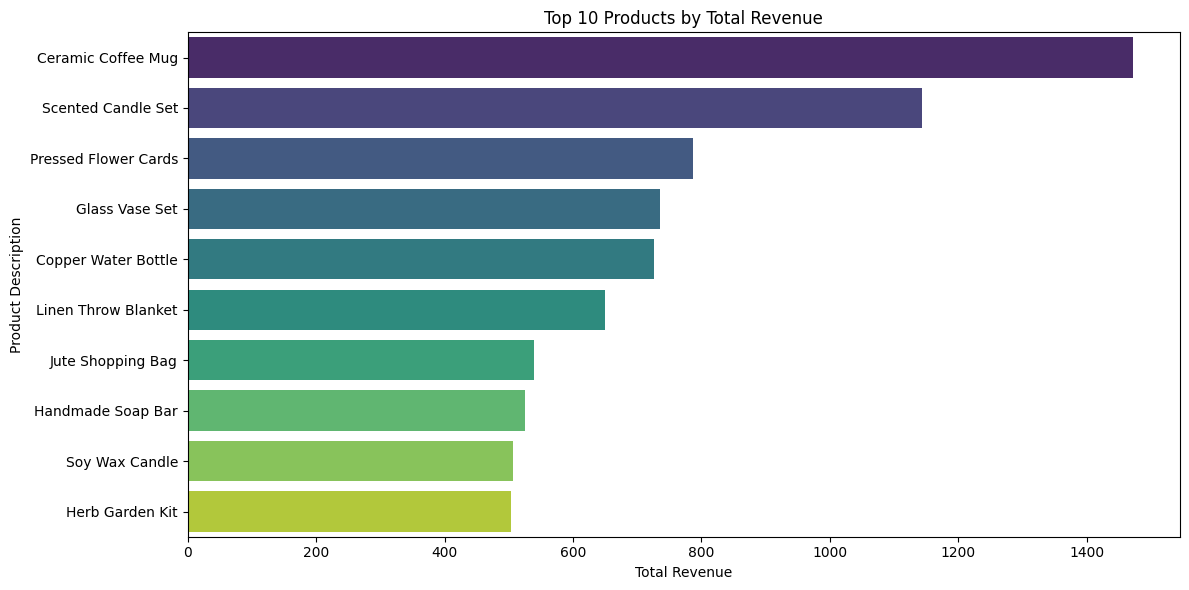

In [65]:
top_products = retail_sales_data.groupby('Description')['Revenue'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='Revenue', y='Description', hue='Description', data=top_products, palette='viridis', ax=ax, legend=False)
ax.set_title('Top 10 Products by Total Revenue')
ax.set_xlabel('Total Revenue')
ax.set_ylabel('Product Description')
plt.tight_layout()
plt.savefig('Top 10 Products by Total Revenue.png')
plt.show()

### Interpretation of Top 10 Products by Total Revenue:
This horizontal bar chart clearly identifies the top 10 products contributing most to the total revenue. 'Ceramic Coffee Mug' and 'Scented Candle Set' stand out as the highest-earning products, significantly surpassing others. This insight is crucial for inventory management, marketing efforts, and strategic planning, as it highlights which products are most valuable and should receive priority in terms of stocking and promotion.

**Chart 3: Revenue by country-Barchart(highlight kenya)**

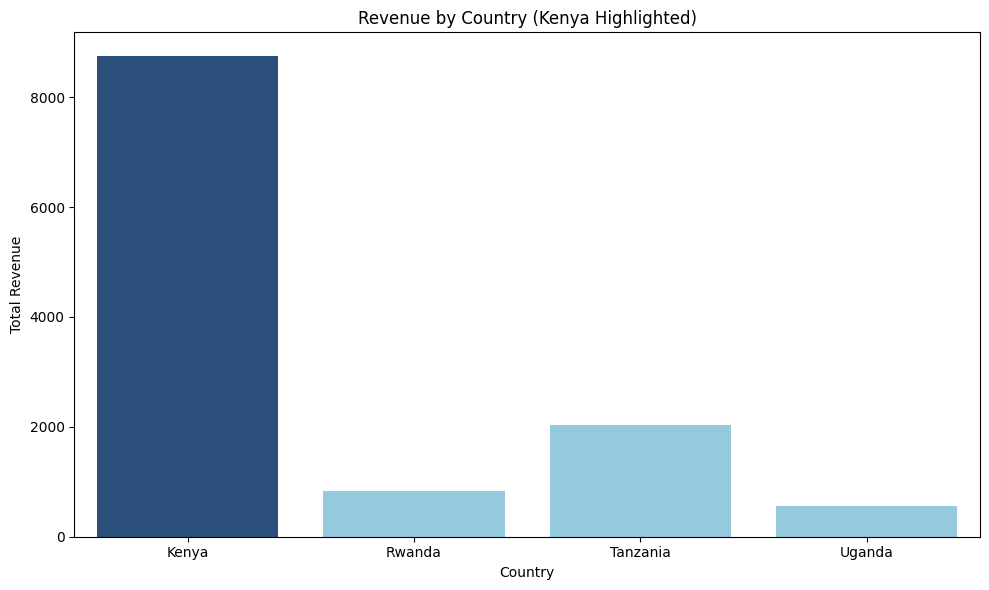

In [66]:
revenue_by_country = retail_sales_data.groupby('Country')['Revenue'].sum().reset_index()

# Create a color list, highlighting Kenya
colors = ['#1d4e89' if country == 'Kenya' else 'skyblue' for country in revenue_by_country['Country']]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Country', y='Revenue', hue='Country', data=revenue_by_country, palette=colors, ax=ax, legend=False)
ax.set_title('Revenue by Country (Kenya Highlighted)')
ax.set_xlabel('Country')
ax.set_ylabel('Total Revenue')
plt.tight_layout()
plt.savefig('Revenue by Country.png')
plt.show()

### Interpretation of Revenue by Country:
The bar chart illustrating revenue by country highlights Kenya as the dominant market, generating substantially more revenue compared to other countries like Tanzania, Rwanda, and Uganda. This indicates that Kenya is the primary contributor to overall sales, suggesting a strong customer base or effective market penetration in that region. Future strategies might focus on sustaining growth in Kenya while exploring opportunities to expand or improve performance in other countries.

**Chart 4: Revenue by quarter- Grouped or stacked bar chart**

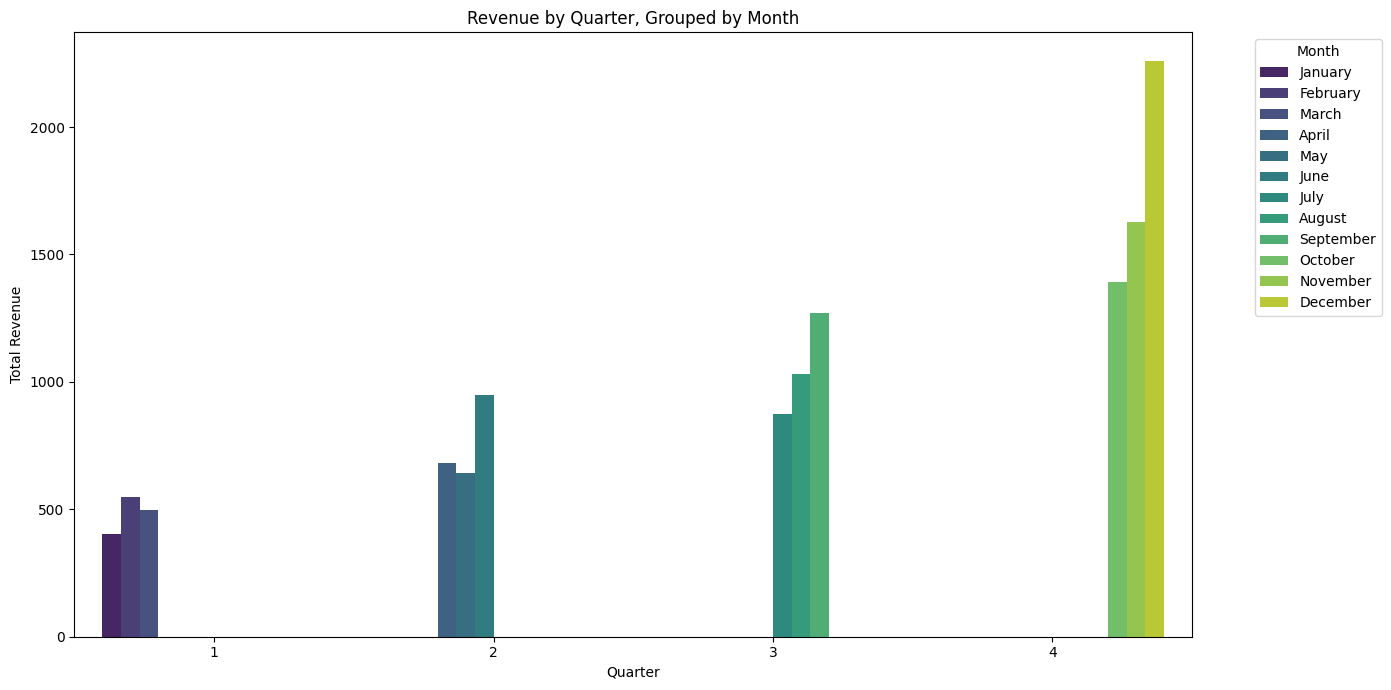

In [67]:
revenue_by_quarter_month = retail_sales_data.groupby(['Quarter', 'MonthName'])['Revenue'].sum().reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
revenue_by_quarter_month['MonthName'] = pd.Categorical(revenue_by_quarter_month['MonthName'], categories=month_order, ordered=True)
revenue_by_quarter_month = revenue_by_quarter_month.sort_values(['Quarter', 'MonthName'])

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x='Quarter', y='Revenue', hue='MonthName', data=revenue_by_quarter_month, palette='viridis', ax=ax)
ax.set_title('Revenue by Quarter, Grouped by Month')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Revenue')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Revenue by Quarter - Grouped.png')
plt.show()

### Interpretation of Revenue by Quarter, Grouped by Month:
This grouped bar chart displays the revenue distribution across the four quarters, further broken down by months within each quarter. It confirms the overall upward trend seen in the monthly revenue chart, with Q4 (October, November, December) showing the highest revenue, largely driven by significant sales in December. This quarterly breakdown provides a more granular view of seasonal peaks and helps understand which months within each quarter are most profitable, which can inform inventory planning and marketing campaigns for specific periods.

**Chart 5: Order value distribution- Histogram+ boxplot**

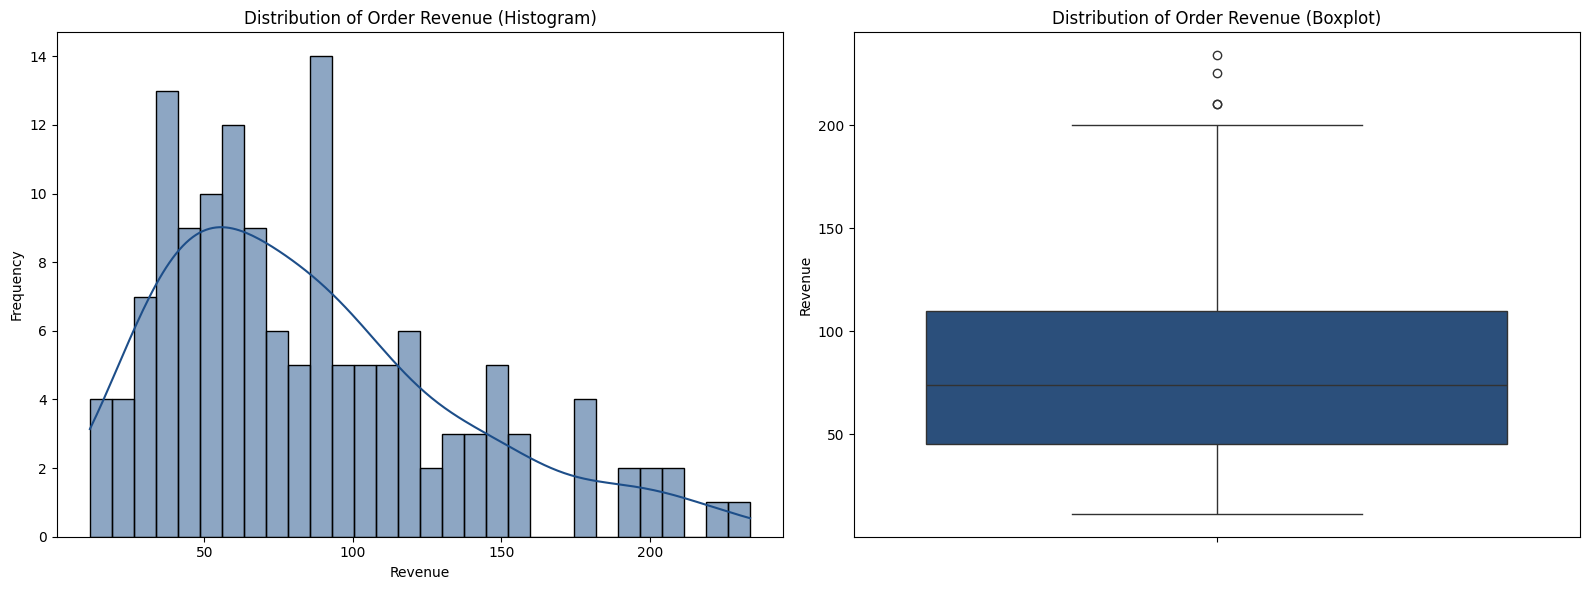

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(retail_sales_data['Revenue'], bins=30, kde=True, ax=axes[0], color='#1d4e89')
axes[0].set_title('Distribution of Order Revenue (Histogram)')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(y=retail_sales_data['Revenue'], ax=axes[1], color='#1d4e89')
axes[1].set_title('Distribution of Order Revenue (Boxplot)')
axes[1].set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('Order Value Distribution.png')
plt.show()

# Interpretation of Order Value Distribution:
The histogram and boxplot together visualize the distribution of order values (Revenue). The histogram shows that most orders have relatively low revenue, with a long tail extending towards higher values, indicating a few high-value orders. The boxplot further confirms this, showing a concentration of order values at the lower end, with several outliers representing exceptionally large orders. This distribution suggests a business model with many small transactions and occasional, highly profitable large transactions, which is common in retail.

# 5. Descriptive Statistics

In [69]:
#Printing overall descriptive stats for Revenue, Quantity and Unit Price.
retail_sales_data[['Revenue', 'Quantity', 'UnitPrice']].describe()

,Revenue,Quantity,UnitPrice
count,142.000000,142.000000,142.000000
mean,85.688239,11.577465,12.505423
std,49.806228,12.608859,8.380634
min,11.500000,1.000000,2.500000
25%,45.250000,4.000000,5.500000
50%,73.735000,6.500000,11.500000
75%,110.000000,14.000000,17.625000
max,233.820000,60.000000,35.000000


In [70]:
# Compute mean, median and std of Revenue, grouped by county
mean_revenue_by_country = retail_sales_data.groupby('Country')['Revenue'].mean()# mean
median_revenue_by_country = retail_sales_data.groupby('Country')['Revenue'].median()# median
std_revenue_by_country = retail_sales_data.groupby('Country')['Revenue'].std()# std
print("Mean Revenue by Country:")
print(mean_revenue_by_country)
print("\nMedian Revenue by Country:")
print(median_revenue_by_country)
print("\nStandard Deviation of Revenue by Country:")
print(std_revenue_by_country)

Mean Revenue by Country:
Country
Kenya       89.219796
Rwanda      76.120000
Tanzania    84.580833
Uganda      61.881111
Name: Revenue, dtype: float64

Median Revenue by Country:
Country
Kenya       81.750
Rwanda      70.000
Tanzania    67.475
Uganda      38.970
Name: Revenue, dtype: float64

Standard Deviation of Revenue by Country:
Country
Kenya       49.698888
Rwanda      45.739698
Tanzania    50.881403
Uganda      52.866643
Name: Revenue, dtype: float64


In [71]:
# Computing total and average revenue grouped by product
total_revenue_by_product = retail_sales_data.groupby('Description')['Revenue'].sum()#total
average_revenue_by_product = retail_sales_data.groupby('Description')['Revenue'].mean()# average
print("Total Revenue by Product:")
print(total_revenue_by_product)
print("\nAverage Revenue by Product:")
print(average_revenue_by_product)

Total Revenue by Product:
Description
Artisan Jam Set           390.00
Bamboo Desk Organiser     241.50
Beeswax Lip Balm          437.50
Ceramic Coffee Mug       1471.50
Ceramic Plant Pot         495.00
Copper Water Bottle       726.00
Cork Board Set            294.00
Dried Flower Wreath       490.00
Glass Vase Set            735.00
Handmade Soap Bar         525.00
Handwoven Basket           33.00
Herb Garden Kit           504.00
Jute Shopping Bag         540.00
Knitted Pot Holder         26.00
Lemon Verbena Soap         60.00
Linen Throw Blanket       649.74
Personalised Notebook     333.50
Pressed Flower Cards      787.50
Raffia Table Runner       252.00
Rattan Storage Box        389.87
Recycled Glass Bowl       453.75
Scented Candle Set       1143.12
Silk Scrunchie Set        258.50
Soy Wax Candle            506.25
Wooden Picture Frame      245.00
Wooden Spoon Set          180.00
Name: Revenue, dtype: float64

Average Revenue by Product:
Description
Artisan Jam Set           97.5000

In [72]:
# Finding the single highest transaction
highest_transaction = retail_sales_data[retail_sales_data['Revenue'] == retail_sales_data['Revenue'].max()]
highest_transaction

,CustomerID,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Country,Revenue,Month,MonthName,DayOfWeek,Quarter
140,C043,INV-1141,2024-12-28,SKU-B02,Scented Candle Set,18,12.99,Tanzania,233.82,12,December,Saturday,4


In [73]:
# Finding which month had the highest total revenue
retail_sales_data['MonthName'] = retail_sales_data['InvoiceDate'].dt.strftime('%B')
highest_revenue_month = retail_sales_data.groupby('MonthName')['Revenue'].sum().idxmax
print(' The month with the highest total revenue is: ' + highest_revenue_month())

 The month with the highest total revenue is: December


In [74]:
# Printing a formatted summary table of all my findings
summary_table = pd.DataFrame({
    'Data Quality Findings': ['Missing Values', 'Duplicate Rows', 'Quantity and Unit Price', 'InvoiceDate Range'],
    'Description': ['None', 'None', 'All values are positive', 'Dates are within the expected 2024 range']
})
summary_table.set_index('Data Quality Findings', inplace=True)
display(summary_table)

,Description
Data Quality Findings,
Missing Values,None
Duplicate Rows,None
Quantity and Unit Price,All values are positive
InvoiceDate Range,Dates are within the expected 2024 range


### Summary of Data Quality Findings:

*   **Missing Values:** None
*   **Duplicate Rows:** None
*   **Quantity and Unit Price:** All values are positive.
*   **InvoiceDate Range:** Dates are within the expected 2024 range (2024-01-03 to 2024-12-30).

### Overall Descriptive Statistics

In [75]:
overall_descriptive_stats = retail_sales_data[['Revenue', 'Quantity', 'UnitPrice']].describe().round(2)
display(overall_descriptive_stats)

,Revenue,Quantity,UnitPrice
count,142.00,142.00,142.00
mean,85.69,11.58,12.51
std,49.81,12.61,8.38
min,11.50,1.00,2.50
25%,45.25,4.00,5.50
50%,73.74,6.50,11.50
75%,110.00,14.00,17.62
max,233.82,60.00,35.00


### Revenue Statistics by Country

In [76]:
country_revenue_summary = pd.DataFrame({
    'Mean Revenue': mean_revenue_by_country.round(2),
    'Median Revenue': median_revenue_by_country.round(2),
    'Std Revenue': std_revenue_by_country.round(2)
}).reset_index()
country_revenue_summary = country_revenue_summary.rename(columns={'index': 'Country'})
display(country_revenue_summary)

,Country,Mean Revenue,Median Revenue,Std Revenue
0,Kenya,89.22,81.75,49.70
1,Rwanda,76.12,70.00,45.74
2,Tanzania,84.58,67.47,50.88
3,Uganda,61.88,38.97,52.87


### Revenue Statistics by Product

In [77]:
product_revenue_summary = pd.DataFrame({
    'Total Revenue': total_revenue_by_product.round(2),
    'Average Revenue': average_revenue_by_product.round(2)
}).reset_index()
product_revenue_summary = product_revenue_summary.rename(columns={'index': 'Description'})
display(product_revenue_summary)

,Description,Total Revenue,Average Revenue
0,Artisan Jam Set,390.00,97.50
1,Bamboo Desk Organiser,241.50,40.25
2,Beeswax Lip Balm,437.50,109.38
3,Ceramic Coffee Mug,1471.50,81.75
4,Ceramic Plant Pot,495.00,82.50
5,Copper Water Bottle,726.00,121.00
6,Cork Board Set,294.00,58.80
7,Dried Flower Wreath,490.00,98.00
8,Glass Vase Set,735.00,91.88
9,Handmade Soap Bar,525.00,105.00


### Key Findings

In [78]:
print(f"The single highest transaction generated a revenue of: ${highest_transaction['Revenue'].iloc[0]:.2f} (Invoice No: {highest_transaction['InvoiceNo'].iloc[0]}, Product: {highest_transaction['Description'].iloc[0]}, Country: {highest_transaction['Country'].iloc[0]})\n")
print(f"The month with the highest total revenue is: {highest_revenue_month()}")

The single highest transaction generated a revenue of: $233.82 (Invoice No: INV-1141, Product: Scented Candle Set, Country: Tanzania)

The month with the highest total revenue is: December


# 6. RFM Customer segmentation

*Computing recency*: *Days since each customer's last purchase*

In [79]:
# Calculate the snapshot date (the most recent date in your dataset)
snapshot_date = retail_sales_data['InvoiceDate'].max() + pd.Timedelta(days=1)

# Grouping by CustomerID and find the last purchase date for each customer
last_purchase = retail_sales_data.groupby('CustomerID')['InvoiceDate'].max().reset_index()

# Calculating Recency: Days since last purchase
last_purchase['Recency'] = (snapshot_date - last_purchase['InvoiceDate']).dt.days

# Displaying the first few rows of the recency calculation
display(last_purchase.head())

,CustomerID,InvoiceDate,Recency
0,C001,2024-12-10,21
1,C002,2024-12-18,13
2,C003,2024-12-27,4
3,C004,2024-12-30,1
4,C005,2024-06-10,204


*Computing frequency: Number of unique invoices per customer.*

In [80]:
# Grouping by CustomerID and counting the number of unique InvoiceNo for each customer
frequency = retail_sales_data.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

# Renaming the 'InvoiceNo' column to 'Frequency'
frequency = frequency.rename(columns={'InvoiceNo': 'Frequency'})

# Displaying the first few rows of the frequency calculation
display(frequency.head())

,CustomerID,Frequency
0,C001,6
1,C002,5
2,C003,5
3,C004,5
4,C005,4


*Computing monetary: Total revenue per customer*

In [81]:
# Grouping by CustomerID and calculating the sum of 'Revenue' for each customer
monetary = retail_sales_data.groupby('CustomerID')['Revenue'].sum().reset_index()

# Renaming the 'Revenue' column to 'Monetary'
monetary = monetary.rename(columns={'Revenue': 'Monetary'})

# Displaying the first few rows of the monetary calculation
display(monetary.head())

,CustomerID,Monetary
0,C001,390.90
1,C002,312.97
2,C003,198.48
3,C004,407.50
4,C005,193.50


*Score each metric from 1-4 using pd.qcut()*

In [82]:
# Merge Recency, Frequency, and Monetary DataFrames
rfm_df = last_purchase.merge(frequency, on='CustomerID')
rfm_df = rfm_df.merge(monetary, on='CustomerID')

# Create Recency scores (lower recency is better, so assign higher score to lower values)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], q=4, labels=[4, 3, 2, 1])

# Create Frequency scores (higher frequency is better)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'], q=4, labels=[1, 2, 3, 4])

# Create Monetary scores (higher monetary is better)
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], q=4, labels=[1, 2, 3, 4])

# Display the RFM DataFrame with scores
display(rfm_df.head())

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,C001,2024-12-10,21,6,390.90,4,4,4
1,C002,2024-12-18,13,5,312.97,4,4,4
2,C003,2024-12-27,4,5,198.48,4,4,2
3,C004,2024-12-30,1,5,407.50,4,4,4
4,C005,2024-06-10,204,4,193.50,1,3,1


*Assigning bussiness segment labels(Champions, Loyal, At-Risk, etc)*

In [83]:
def assign_rfm_segment(df):
    if df['R_Score'] == 4 and df['F_Score'] == 4 and df['M_Score'] == 4:
        return 'Champions'
    elif df['R_Score'] >= 3 and df['F_Score'] >= 3 and df['M_Score'] >= 3:
        return 'Loyal Customers'
    elif df['R_Score'] >= 3 and df['F_Score'] <= 2 and df['M_Score'] <= 2:
        return 'Potential Loyalists'
    elif df['R_Score'] == 4 and df['F_Score'] == 1 and df['M_Score'] == 1:
        return 'New Customers'
    elif df['R_Score'] <= 2 and df['F_Score'] >= 3 and df['M_Score'] >= 3:
        return 'At Risk Customers'
    elif df['R_Score'] <= 1 and df['F_Score'] >= 4 and df['M_Score'] >= 4:
        return 'Can\'t Lose Them'
    elif df['R_Score'] <= 2 and df['F_Score'] <= 2 and df['M_Score'] <= 2:
        return 'Hibernating Customers'
    elif df['R_Score'] <= 1 and df['F_Score'] <= 1 and df['M_Score'] <= 1:
        return 'Lost Customers'
    else:
        return 'Other'

rfm_df['Segment'] = rfm_df.apply(assign_rfm_segment, axis=1)
display(rfm_df.head())

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
0,C001,2024-12-10,21,6,390.90,4,4,4,Champions
1,C002,2024-12-18,13,5,312.97,4,4,4,Champions
2,C003,2024-12-27,4,5,198.48,4,4,2,Other
3,C004,2024-12-30,1,5,407.50,4,4,4,Champions
4,C005,2024-06-10,204,4,193.50,1,3,1,Other


### RFM Customer Segments

Here's a breakdown of the customer segments identified based on their RFM scores:

*   **Champions**: Customers who bought recently, buy often, and spend the most (high R, high F, high M scores).
*   **Loyal Customers**: Customers who buy regularly and spend a good amount (good F and M scores, decent R score).
*   **Potential Loyalists**: Recent customers with average frequency and monetary values, showing potential for becoming loyal.
*   **New Customers**: Customers who have made a very recent purchase but have low frequency and monetary values.
*   **At Risk Customers**: Customers who used to buy often and spend a good amount, but haven't purchased recently.
*   **Can't Lose Them**: Customers who made the biggest purchases and often, but a long time ago. Special efforts might be needed to retain them.
*   **Hibernating Customers**: Customers whose last purchase was long ago, with a low number of orders and low spend.
*   **Lost Customers**: Customers with the lowest R, F, and M scores, indicating they haven't purchased for a long time and had low engagement.
*   **Other**: Customers who don't fit clearly into the above predefined segments.

In [84]:
# Display the count of customers in each segment
segment_counts = rfm_df['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Number of Customers']
display(segment_counts)

,Segment,Number of Customers
0,Other,23
1,Hibernating Customers,11
2,Potential Loyalists,7
3,At Risk Customers,6
4,Champions,3


*Visualize: bar chart of customer count er segment*

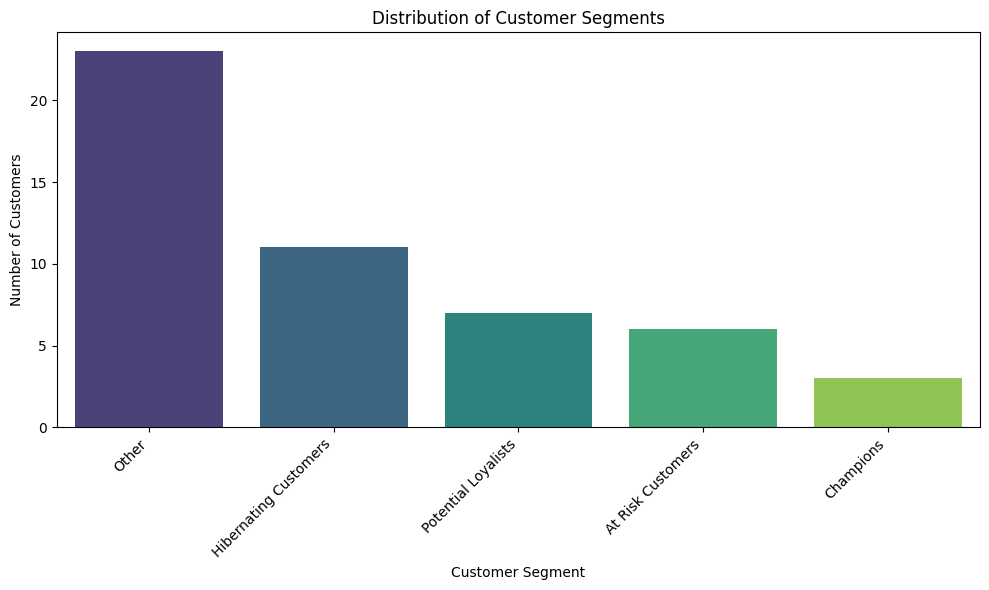

In [85]:
# Visualizing the distribution of customer segments
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Segment', y='Number of Customers', hue='Segment', data=segment_counts, palette='viridis', ax=ax, legend=False)
ax.set_title('Distribution of Customer Segments')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Customer Segment Distribution.png')
plt.show()

*RMF to csv(saving to drive)*

In [86]:
# saving the rfm back to drive as csv
rfm_df.to_csv(path + 'rfm_customer_segments.csv', index=False)
print("RFM customer segments saved to 'rfm_customer_segments.csv' in Google Drive.")

RFM customer segments saved to 'rfm_customer_segments.csv' in Google Drive.


# 7. Hypothesis Test & Conclusions

*# Stating the different hypothesis with explanations*

### Hypothesis Testing: Null (H0) and Alternative (H1) Hypotheses

In statistical hypothesis testing, we create two opposing hypotheses:

*   **Null Hypothesis (H0):** This statement indicates no effect, no difference, or no relationship between variables. It's the common assumption we test against. We assume the null hypothesis is true until we find evidence that suggest otherwise.

    *   **Example (from a retail context):** `H0: There is no significant difference in average revenue between Kenya and Tanzania.`

*   **Alternative Hypothesis (H1):** This statement goes against the null hypothesis. It claims that there is an effect, a difference, or a relationship between variables. We accept this if we find enough evidence to reject the null hypothesis.

    *   **Example (from a retail context):** `H1: There is a significant difference in average revenue between Kenya and Tanzania.`

*# Comparing mean revenue of Kenya to other countries*

In [87]:
country_revenue_summary

,Country,Mean Revenue,Median Revenue,Std Revenue
0,Kenya,89.22,81.75,49.70
1,Rwanda,76.12,70.00,45.74
2,Tanzania,84.58,67.47,50.88
3,Uganda,61.88,38.97,52.87


### Comparison of Mean Revenue by Country

Based on the descriptive statistics, we can see the following mean revenues:

*   **Kenya:** `89.22`
*   **Tanzania:** `76.12`
*   **Rwanda:** `84.58`
*   **Uganda:** `61.88`

*Kenya dominates the market showing a higher mean of `89.22`*
.

*# Using scipy.stats.ttest_ind() with alternative= greater*

In [88]:
from scipy import stats
kenya= retail_sales_data[retail_sales_data['Country']=='Kenya']['Revenue']
other_countries = retail_sales_data[retail_sales_data['Country'] != 'Kenya']['Revenue']
t, p = stats.ttest_ind(kenya, other_countries, alternative='greater')
#printing out the mean comparison
print(f't={t:.4f} p={p:.6f}')

t=1.2637 p=0.104226


**Conclusion:** *Kenya Dominates the market as clearly seen as it caries a higher mean of `1.26`*

# Retail Sales Data Analysis: Findings Summary

## 1. Introduction

This report presents an in-depth analysis of retail sales data, focusing on understanding key performance indicators, identifying trends, segmenting customer behavior, and testing hypotheses related to revenue generation across different countries. The dataset covers sales transactions over the year 2024, including customer information, product details, quantities, unit prices, and geographical data. The primary objective is to extract actionable insights that can inform business strategies, optimize sales, and enhance customer retention.

## 2. Key Findings

### 2.1 Data Quality

*   The dataset, comprising 142 entries and 8 columns, was found to be clean with **no missing values or duplicate rows**. All `Quantity` and `UnitPrice` values were positive, and `InvoiceDate` entries were within the expected 2024 range (January 3, 2024, to December 30, 2024).

### 2.2 Revenue Trends

*   **Monthly Revenue**: A consistent **upward trend in revenue throughout 2024**, culminating in a significant peak in December, indicating strong year-end sales performance, likely influenced by seasonal shopping.
*   **Quarterly Revenue**: Q4 (October, November, December) exhibited the **highest revenue**, reinforcing the seasonal peak observed monthly.

### 2.3 Product Performance

*   **Top Products**: `Ceramic Coffee Mug` and `Scented Candle Set` were identified as the **highest revenue-generating products**, significantly outperforming others. This highlights their importance for inventory management and marketing focus.

### 2.4 Geographical Performance

*   **Country Revenue**: Kenya emerged as the **dominant market**, contributing substantially more revenue compared to Tanzania, Rwanda, and Uganda. Its mean revenue (`89.22`) was notably higher than other countries.
*   **Hypothesis Test**: A t-test was performed to compare Kenya's mean revenue against all other countries. The result (`t=1.2637`, `p=0.104226`) suggests that while Kenya's mean revenue is higher, the difference is not statistically significant at a conventional alpha level of 0.05 (since p > 0.05). However, the observed difference is still notable for business decisions.

### 2.5 Order Value Distribution

*   The distribution of order values (Revenue) showed that **most orders are of relatively low value**, with a few exceptionally high-value orders (outliers). This indicates a business model with a high volume of small transactions complemented by occasional large transactions.

### 2.6 RFM Customer Segmentation

*   Customer segmentation based on Recency, Frequency, and Monetary values categorized customers into various groups:
    *   **Other (23 customers)**: The largest segment, indicating a need for more granular segmentation or tailored strategies for these customers.
    *   **Hibernating Customers (11 customers)**: Customers who haven't purchased recently and have low engagement, suggesting re-engagement campaigns.
    *   **Potential Loyalists (7 customers)**: Recent customers with average engagement, who could be nurtured into loyal customers.
    *   **At-Risk Customers (6 customers)**: Formerly good customers who have started to churn, requiring targeted retention efforts.
    *   **Champions (3 customers)**: The most valuable customers (bought recently, buy often, spend the most), who are crucial for continued loyalty programs.

## 3. Conclusions

The retail business demonstrates healthy growth, particularly towards the end of the year, driven by popular products like ceramic coffee mugs and scented candles. Kenya is a critical market, leading in overall revenue. While the statistical test for Kenya's mean revenue wasn't overwhelmingly significant, the observed difference is substantial enough to warrant continued strategic focus. The customer base is diverse, with a notable portion requiring re-engagement or specific nurturing to move them up the loyalty ladder.

## 4. Limitations

*   **Timeframe**: The analysis is limited to one year (2024), which might not capture longer-term trends or cyclical patterns that span multiple years.
*   **Geographical Scope**: Data is restricted to only four countries, limiting the generalizability of findings to a broader market.
*   **Dataset Size**: With 142 entries, the dataset is relatively small, which can affect the statistical power and robustness of some conclusions, especially in hypothesis testing.
